# Homework 6: N-Gram Language Models with the Austen Corpus

**Due: Sunday, October 11**

> **Late submissions:** There is a grace period until **2:00 AM** following the due date. After 2:00 AM, a **10% late penalty is applied for each 24-hour period**. Submissions more than **5 days late receive a score of 0**.

In this assignment, you will build a complete **probabilistic language model (PLM)** using N-grams and use it to generate and evaluate text from the Jane Austen corpus.

You will begin by constructing **bigram and trigram** probability models, then use them to generate sentences with **backoff** and **temperature-controlled sampling**. You will next introduce **Average Log Probability (ALP)** and **perplexity** to score generated sentences, and finally implement **beam search** to explore high-probability sequences more systematically.

The goal is to understand how relatively simple statistical models can represent patterns in natural language, and how choices in **sampling, scoring, and search** affect the text they produce.

### Learning Objectives

By the end of this homework, you should be able to:

* Build **bigram and trigram** probabilistic language models.
* Represent probabilities in **log space** to avoid numerical underflow.
* Generate sentences using **trigram contexts with bigram backoff**.
* Use **temperature scaling** to control the randomness of generated text.
* Calculate **Average Log Probability (ALP)** and **perplexity** to score generated sequences.
* Implement **beam search** and compare its behavior with ordinary temperature-based sampling.

### The Four Problems

1. **Problem 1 — Build the PLM (Bigrams & Trigrams)**  
   Construct bigram and trigram models from the Austen corpus and convert next-token frequencies into **log-probability distributions**.

2. **Problem 2 — Generating Sentences with Backoff and Temperature**  
   Generate complete sentences using trigram contexts when available, **backing off to bigrams** when necessary. Explore how different **temperatures** affect repetition, diversity, and coherence.

3. **Problem 3 — Average Log Probability and Perplexity**  
   Track the probability of each generated token in log space, use **Average Log Probability (ALP)** to account for sequence length, and compute **perplexity** to compare completed sequences.

4. **Problem 4 — Beam Search**  
   Implement **beam search** by maintaining several promising partial sentences at each step. Use accumulated log probability to rank equal-length partial candidates, use **perplexity** to compare completed sentences, and examine how beam search differs from ordinary temperature sampling.

By the end, you will have built a working N-gram text generator and explored several important ideas—**conditional probability, backoff, temperature, perplexity, and beam search**—that continue to play important roles in modern language modeling.

## Recommended PROTOTYPING Workflow (Must Read!)

One of the most important skills in machine learning is following a **disciplined prototyping workflow** when developing complex code. The basic idea is simple:

1. **Start small:** Write and test your code using a tiny subset of the dataset.
2. **Inspect your results:** Print and examine intermediate outputs to verify that each step behaves as expected.
3. **Iterate and debug:** Fix problems and continue testing, increasing the amount of data as needed.
4. **Scale up:** Once you are confident that your code is working correctly, run it on the full dataset to obtain your final results.

To support this workflow, the **Data Throttle** cell near the beginning of the notebook defines:

```python
num_sentences
```

This variable controls how many sentences from the shuffled Austen corpus are used throughout the notebook.

I recommend the following progression:

- **Step 1 — Debugging:** Begin with:

  ```python
  num_sentences = 10
  ```

  Use this small dataset to inspect intermediate data structures and make sure your code works as expected.

- **Step 2 — Development:** Increase to:

  ```python
  num_sentences = 100
  ```

  Use this larger subset to verify that your code continues to work correctly and to complete most of the homework efficiently.

- **Step 3 — Final run:** When your code is working, use the complete corpus:

  ```python
  num_sentences = None
  ```

  Then rerun the notebook from the **Data Throttle** cell and use these full-corpus results when answering the graded questions.

If a full run is impractical on your computer, use as large a subset as your resources reasonably allow.


In [1]:
import math
import re
import string
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
from matplotlib import pyplot as plt
from collections import Counter

random.seed(42)

#### Utility Function to Pretty-Print Sentences

In [2]:
'''
Reconstruct a human-readable sentence from tokens.
- Capitalize the first token (after removing <s>).
- Attach any token in string.punctuation with no preceding space.
- Attach tokens starting with an apostrophe (e.g., "'s", "'ll") with no space.
- Capitalize standalone 'i' and 'god' wherever they appear.
- If the last token is '.', '?', or '!', attach it without a space.
- Ignore boundary markers <s> and </s> if present.
Returns the sentence string and also prints it.
'''

def print_sentence(tokens):

    if not tokens:
        print("")
        return ""

    # Drop boundary markers if present
    start = 1 if tokens and tokens[0] == "<s>" else 0
    end = -1 if tokens and tokens[-1] == "</s>" else len(tokens)
    core = tokens[start:end]

    if not core:
        print("")
        return ""

    # Capitalize first token
    out = core[0].capitalize()

    # Process remaining tokens with spacing rules
    for i, t in enumerate(core[1:], start=1):
        is_last = (i == len(core) - 1)

        # Last-token punctuation rule
        if is_last and t in {".", "?", "!"}:
            out += t
            continue

        # General punctuation attaches with no space (e.g., ',', ':', ';', ')', etc.)
        if t in string.punctuation:
            out += t
            continue

        # Apostrophe-start tokens like "'s", "'d", "'ll"
        if t.startswith("'"):
            out += t
            continue

        # Capitalize special standalone words
        if t.lower() in {"i", "god"}:
            out += " " + t.capitalize()
            continue

        # Default: add a space before normal words
        out += " " + t

    print(out)
    return out


### Data Throttle

In [3]:
# --------------------------------------------------
# Control corpus size
# --------------------------------------------------

# Recommended progression:
#
#   10      -> debugging
#   100     -> development
#   None    -> full corpus

num_sentences = None

### Read in the list of all sentences in the NLTK Austen Corpus

In [4]:
# --------------------------------------------------
# Load Jane Austen corpus from NLTK Gutenberg
# --------------------------------------------------

import random
import nltk
from nltk.corpus import gutenberg

nltk.download("gutenberg", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)


# --------------------------------------------------
# Jane Austen novels available in NLTK
# --------------------------------------------------

austen_files = [
    "austen-emma.txt",
    "austen-persuasion.txt",
    "austen-sense.txt",
]


# --------------------------------------------------
# Combine sentences from all three novels
# --------------------------------------------------

all_sentences = []

for filename in austen_files:
    all_sentences.extend(
        gutenberg.sents(filename)
    )


# --------------------------------------------------
# Shuffle once, reproducibly
# --------------------------------------------------

random_seed = 42

rng = random.Random(random_seed)
rng.shuffle(all_sentences)

if num_sentences is None:
    selected_sentences = all_sentences
else:
    selected_sentences = all_sentences[:num_sentences]


# --------------------------------------------------
# Normalize and add sentence-boundary markers
# --------------------------------------------------

tokenized_sentences = []

for sentence in selected_sentences:

    tokens = [
        token.lower()
        for token in sentence
        if token.strip()
    ]

    if tokens:
        tokenized_sentences.append(
            ["<s>"] + tokens + ["</s>"]
        )

### Examine some sentences

In [5]:
# Display first N sentences in text and list form

N = 10

for k in range(N):
    if num_sentences != None and (k >= num_sentences):
        break
    print_sentence(tokenized_sentences[k]) 
    print()
    print(tokenized_sentences[k]) 
    print()

' my dear madam ,' I always say to her,' you must make yourself easy.

['<s>', "'", 'my', 'dear', 'madam', ",'", 'i', 'always', 'say', 'to', 'her', ',', "'", 'you', 'must', 'make', 'yourself', 'easy', '.', '</s>']

"` mr.

['<s>', '"`', 'mr', '.', '</s>']

A poet in love must be encouraged in both capacities, or neither.

['<s>', 'a', 'poet', 'in', 'love', 'must', 'be', 'encouraged', 'in', 'both', 'capacities', ',', 'or', 'neither', '.', '</s>']

" thank you, willoughby.

['<s>', '"', 'thank', 'you', ',', 'willoughby', '.', '</s>']

He did consent.

['<s>', 'he', 'did', 'consent', '.', '</s>']

She went -- she had driven once unsuccessfully to the door, but had not been into the house since the morning after box hill, when poor jane had been in such distress as had filled her with compassion, though all the worst of her sufferings had been unsuspected .-- the fear of being still unwelcome, determined her, though assured of their being at home, to wait in the passage, and send up her na

In [6]:
# --------------------------------------------------
# Basic corpus statistics
# --------------------------------------------------

# Remove sentence-boundary markers
all_tokens = [
    token
    for sentence in tokenized_sentences
    for token in sentence
    if token not in {"<s>", "</s>"}
]


def is_word(token):
    return (
        token.isalpha()
        or token.replace("'", "").isalpha()
    )


words = [
    token
    for token in all_tokens
    if is_word(token)
]


num_tokens = len(all_tokens)
num_unique_tokens = len(set(all_tokens))

num_words = len(words)
num_unique_words = len(set(words))

sentence_lengths = [
    len(sentence) - 2       # exclude <s> and </s>
    for sentence in tokenized_sentences
]


print(f"Total number of sentences: {len(tokenized_sentences):,}")
print(f"Total number of tokens:    {num_tokens:,}")
print(f"Number of unique tokens:   {num_unique_tokens:,}")
print(f"Total number of words:     {num_words:,}")
print(f"Number of unique words:    {num_unique_words:,}")


Total number of sentences: 16,498
Total number of tokens:    432,273
Number of unique tokens:   10,642
Total number of words:     366,454
Number of unique words:    10,294


### Digression: Zipf's Law

Zipf's Law is an empirical regularity of natural language:  
if you rank words by their frequency in a corpus, the frequency \( f(r) \) of the word at rank \( r \) is approximately inversely proportional to its rank:

$$
f(r) \propto \frac{1}{r^k}
$$

where $ r = 1, 2, 3, \dots $ is the rank of a word (1 = most frequent), and $ k \approx 1 $.  

- The most common words (e.g., *the*, *of*, *and*) occur very often.  
- A handful of mid-ranked words occur moderately often.  
- The vast majority of words occur rarely.  

On a **log–log plot** of frequency vs. rank, this relationship appears as a straight line with slope $-k$.  
For natural language, empirical studies show that $k \approx 1$, which is why we plot below a reference line with slope $-1$ to compare against real corpus data.


**Why this matters:** Because most words are rare, language models must use techniques like **smoothing, subword modeling, or embeddings** to handle sparsity and represent meaning effectively.  


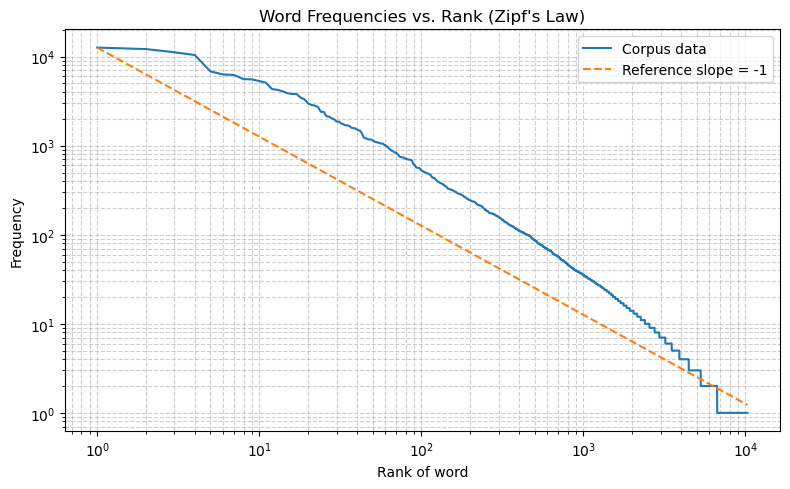

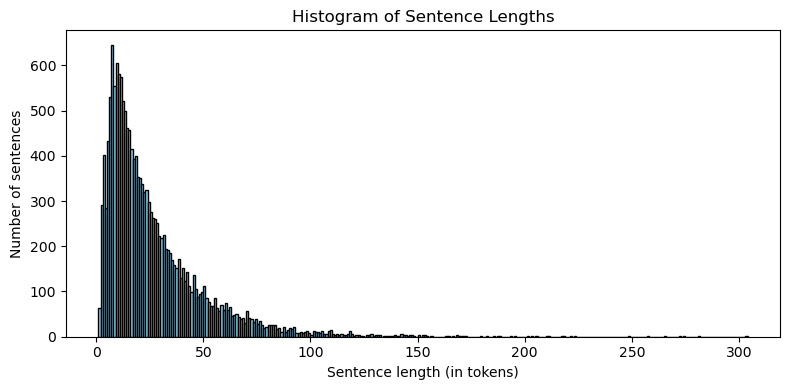

Average sentence length: 26.20 tokens
Max sentence length:     303 tokens


In [7]:
from collections import Counter

# --------------------------------------------------
# Word frequencies
# --------------------------------------------------

# Count words only, excluding punctuation and
# sentence-boundary markers
word_counts = Counter(
    token
    for sentence in tokenized_sentences
    for token in sentence
    if is_word(token)
)

# Frequencies sorted by rank
freqs = np.array([
    freq
    for token, freq in word_counts.most_common()
])

ranks = np.arange(1, len(freqs) + 1)

plt.figure(figsize=(8, 5))
plt.plot(ranks, freqs, label="Corpus data")

# Reference line: slope = -1 (Zipf's law)
# Match scale by anchoring at the first frequency
ref_line = freqs[0] / ranks
plt.plot(
    ranks,
    ref_line,
    "--",
    label="Reference slope = -1"
)

plt.xscale("log")
plt.yscale("log")
plt.title("Word Frequencies vs. Rank (Zipf's Law)")
plt.xlabel("Rank of word")
plt.ylabel("Frequency")
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


# --------------------------------------------------
# Sentence lengths
# --------------------------------------------------

# Subtract the <s> and </s> boundary tokens
sentence_lengths = [
    len(sentence) - 2
    for sentence in tokenized_sentences
]

plt.figure(figsize=(8, 4))
plt.hist(
    sentence_lengths,
    bins=range(1, max(sentence_lengths) + 2),
    color="skyblue",
    edgecolor="black"
)

plt.title("Histogram of Sentence Lengths")
plt.xlabel("Sentence length (in tokens)")
plt.ylabel("Number of sentences")
plt.tight_layout()
plt.show()

print(
    f"Average sentence length: "
    f"{np.mean(sentence_lengths):.2f} tokens"
)

print(
    f"Max sentence length:     "
    f"{max(sentence_lengths)} tokens"
)

## Problem One — Build the PLM (Bigrams & Trigrams)

For this problem, you will adapt code from this week’s Coding Notebook to build a probabilistic language model using both **bigrams** and **trigrams**.

The corpus has already been prepared above. Each sentence is represented as a list of tokens and is enclosed by the sentence-boundary tokens `<s>` and `</s>`.

For your initial development, set:

```python
num_sentences = 10
```

in the **Data Throttle** cell above, then rerun the notebook from that point.

### To Do

### A. Build N-grams for N = 2 and N = 3

Compute all **bigrams** and **trigrams** over `tokenized_sentences`, including the sentence-boundary tokens.

Your code should work for a general value of `N`.

---

### B. Create a dictionary mapping left contexts to next-token lists

For each bigram and trigram:

- use the first `N-1` tokens as the **left context**
- use the final token as the **next token**
- store all observed next tokens in a list

Allow duplicate next tokens so that their frequency in the list represents their observed count.

For example, a bigram context has the form:

```python
('the',)
```

while a trigram context has the form:

```python
('<s>', 'he')
```

Store both bigram and trigram contexts in a single dictionary named:

```python
next_word_lists
```

This works because bigram and trigram contexts have different tuple lengths.

---

### C. Convert to log-probability distributions

Convert each context’s list of next tokens into a probability distribution based on relative frequency, then store the probabilities in **log space**.

For each context, the result should have the form:

```python
{
    next_token_1: log_probability_1,
    next_token_2: log_probability_2,
    ...
}
```

See **Appendix** for a review of log probabilities.

---

### D. Create the Probability Language Model (PLM)

Create a dictionary named:

```python
get_next_word
```

with:

- **Key:** a left-context tuple
- **Value:** a dictionary mapping possible next tokens to their log probabilities

For example:

```python
get_next_word[('the',)]
```

should return a dictionary of possible tokens that can follow `the`, together with their log probabilities.

Use a single dictionary for both bigram and trigram contexts.

---

### E. Sanity-check your model

With `num_sentences = 10`, inspect several entries in `get_next_word` to verify that your model was constructed correctly.

For example, display the distributions for:

```python
('<s>',)
('the',)
('<s>', 'he')
```

If one of these contexts does not occur in your 10-sentence sample, choose another context that does.

---

### F. Sample possible next tokens

Using the same three contexts from Part E, generate **5 possible next tokens** for each context by sampling according to the probability distribution stored in `get_next_word`.

Because the model stores probabilities in log space, remember to convert them back to ordinary probabilities before using them as sampling weights.

---

**Then answer the graded questions.**


In [8]:
# Your code here (add as many cells as you need)


### Graded Questions

**A.** Using your completed PLM, set `a1a` to the **most likely next token** for the trigram context:

```python
('<s>', 'the')
```

If this context does not appear with your current `num_sentences` setting, increase the corpus size as described in the prototyping workflow.

In [9]:
# Your answer here

a1a = ''                  # Replace with your answer

In [10]:
# Graded Answer
# DO NOT change this cell in any way and do not make any other assignments to variable a1 in this problem         

print(f'a1a = {a1a}') 


a1a = 


**B.** Why can the bigram and trigram probability distributions be stored safely in the same `get_next_word` dictionary?

Set `a1b` to the number of the best answer.

1. Bigram and trigram contexts always contain different words.
2. Bigram contexts contain one token, while trigram contexts contain two tokens, so their tuple keys cannot be confused.
3. Python automatically stores bigrams and trigrams in separate parts of a dictionary.
4. The log probabilities identify whether a context came from a bigram or trigram.

In [11]:
# Your answer here

a1b = 0                   # Replace with your answer

In [12]:
# Graded Answer
# DO NOT change this cell in any way and do not make any other assignments to variable a1 in this problem         

print(f'a1b = {a1b}') 


a1b = 0


## Problem Two — Generating Sentences with Backoff and Temperature

In this problem, you will use the probabilistic language model from Problem One to generate complete sentences.

At each step, the generator examines the most recent tokens in the sentence, finds the corresponding conditional probability distribution, samples the next token, and continues until the end-of-sentence token `</s>` is generated.

For **bigrams**, this is straightforward: each token observed in the corpus has at least one possible continuation.

For **trigrams**, two additional issues must be handled.

### 1. Cold Start: Not Enough Left Context

At the beginning of a sentence, there are not yet two previous tokens available to form a trigram context.

For example:

```text
                                      Use:

Step 1:    <s> ?                     bigram
Step 2:    <s> one ?                 trigram
Step 3:    <s> one fish ?            trigram
```

Your code can handle this naturally by using whatever left context is currently available.

For example:

```python
left_context = tuple(sentence[-2:])
```

produces a one-token context at the beginning of the sentence and a two-token context thereafter.

---

### 2. Sparsity: Missing Trigram Contexts

Even after two previous tokens are available, their trigram context may never have appeared in the corpus.

For example, suppose the sentence generated so far is:

```text
one fish dish ...
```

If the context

```python
('fish', 'dish')
```

does not occur in the model, there is no trigram probability distribution available for the next token.

In this case, use **backoff**:

> If the trigram context does not exist, drop the earliest token and use the corresponding bigram context instead.

Thus, if:

```python
('fish', 'dish')
```

is unavailable, try:

```python
('dish',)
```

With the bigram and trigram models constructed in Problem One, the basic decision is:

```text
if the trigram context exists:
    use the trigram distribution
else:
    use the bigram distribution
```

---

### Temperature-Controlled Sampling

Once you have selected the appropriate probability distribution, use **temperature scaling** before sampling the next token.

Temperature controls how strongly the generator favors high-probability choices:

- **Low temperature** concentrates probability on the most likely tokens, producing more conservative and often more repetitive text.
- **Temperature = 1.0** uses the model probabilities without changing their relative shape.
- **High temperature** produces a flatter distribution, increasing variety but usually reducing coherence.

Your PLM stores probabilities in **log space**, so remember to convert them back to ordinary probabilities before applying temperature scaling and using them as sampling weights.

---

### To Do

### A. Implement temperature-controlled sampling

Write a function that:

1. obtains the log-probability distribution for a left context;
2. converts the log probabilities back to ordinary probabilities;
3. applies temperature scaling;
4. samples and returns one next token.

---

### B. Implement sentence generation with backoff

Write a sentence generator that:

1. begins with:

```python
['<s>']
```

2. uses the trigram context whenever it exists;
3. backs off to the corresponding bigram context when necessary;
4. appends each sampled token to the sentence;
5. stops when `</s>` is generated.

To prevent runaway generation, also stop if **40 tokens** have been generated without producing `</s>`.

---

### C. Compare three temperatures

Using the **full Austen corpus if possible**, generate **10 sentences** at each of the following temperatures:

```python
0.2
1.0
5.0
```

Print each generated sentence using `print_sentence()`.

Compare the results qualitatively. In particular, look for differences in:

- repetition,
- diversity,
- grammatical or local coherence,
- overall sentence plausibility.

You should expect the three temperatures to produce noticeably different behavior.

---

**Then answer the graded questions.**


### Graded Questions

#### Part A

What is the main effect of **increasing the temperature** used for next-token sampling?

Set `a2a` to the number of the best answer.

1. It makes the probability distribution more concentrated on the highest-probability tokens.
2. It makes the probability distribution flatter, so lower-probability tokens are more likely to be sampled.
3. It changes the probabilities stored in `get_next_word`.
4. It causes the generator to back off from trigrams to bigrams more often.



In [24]:
# Your answer here

a2a = 0                  # Replace with one of 1, 2, 3, 4

In [25]:
# Graded Answer
# DO NOT change this cell in any way and do not make any other assignments to variable a1 in this problem         

print(f'a2a = {a2a}') 


a2a = 0


#### Part B

Compare the sentences generated using temperatures `0.2`, `1.0`, and `5.0`.

In a few sentences, describe the differences you observed in **repetition, diversity, and coherence**. Which temperature seemed to produce the most realistic sentences in your run, and why?

Store your response in `a2b`.


In [26]:
# Your answer here, NOT in the next cell

a2b = """
Write your reflection here.
"""

In [27]:
# Graded Answer
# DO NOT change this cell in any way and do not make any other assignments to variable a1 in this problem         

print(f'a2b = {a2b}') 


a2b = 
Write your reflection here.



## Problem Three — Measuring Sentence Quality with Average Log Probability and Perplexity

The probabilities involved when we calculate the probability of longer token sequences can become extremely small, so numerical underflow is a concern. For this reason, we perform these calculations in **log space** (see **Appendix**).

At a basic level, we can evaluate a generated sentence by its **likelihood under the model**: sentences with higher probability are considered more likely by the model.

However, raw sentence probability is strongly affected by sentence length. Longer sentences involve more probability terms, so their total probability tends to become much smaller even when the individual word choices are reasonable.

To reduce this length effect, we use **Average Log Probability (ALP)** and **Perplexity**.

---

### Average Log Probability (ALP)

Let the tokenized sentence be

$$
[t_1, t_2, \dots, t_n]
$$

with

$$
t_1 = \texttt{<s>}
$$

and, for a completed sentence,

$$
t_n = \texttt{</s>}.
$$

For a trigram model with bigram backoff:

$$
\text{ALP}
=
\frac{
\log P(t_2 \mid t_1)
+
\log P(t_3 \mid t_1,t_2)
+
\cdots
+
\log P(t_n \mid t_{n-2},t_{n-1})
}{
n-1
}
$$

when the trigram contexts exist.

If a trigram context is unavailable, use the log probability from the corresponding **bigram** context instead.

### Notes

- We do not include the initial `<s>` token in the score because it is supplied to the model rather than predicted.
- A sequence containing \(n\) tokens including `<s>` contains exactly \(n-1\) predictions.
- ALP lies in

$$
(-\infty, 0]
$$

and **larger values are better**.
- A less negative ALP means that, on average, the model assigned higher probability to the generated tokens.

---

### Perplexity

Perplexity rescales ALP into a positive quantity:

```python
PP = np.exp(-ALP)
```

Perplexity is always at least 1:

$$
\text{PP} \ge 1
$$

and **smaller values are better**.

Intuitively, perplexity measures how uncertain or "confused" the model is when predicting the sequence. Lower perplexity means that the generated tokens were, on average, assigned higher probability by the model.

Because the exponential function is monotonic:

- maximizing ALP
- and minimizing perplexity

produce the same ranking of sentences.

> **Important:** In the remaining problems, use ALP to compare sequences of different lengths. When candidate sequences all have the same length, as they do within each step of beam search, accumulated log probability gives the same ranking. Use perplexity to report and compare completed sentences.

---

### Sampling and Scoring Are Different

Temperature changes the probability distribution used to **sample** the next token.

However, when evaluating the generated sentence, score each chosen token using the model's original **untempered log probability**.

In other words:

> **Sample using the temperature-adjusted probabilities, but score using the original model probabilities.**

This allows sentences generated at different temperatures to be evaluated using the same underlying language model.

---

### Carrying the Score During Generation

You can calculate the sentence score while the sentence is being generated.

Instead of storing only:

```python
tokens_so_far
```

maintain a pair:

```python
(tokens_so_far, sum_log_probs)
```

where `sum_log_probs` is the sum of the original log probabilities of all tokens generated so far.

For example:

```text
sum_log_probs =
    log P(t2 | t1)
  + log P(t3 | t1, t2)
  + ...
```

If backoff is used for a particular token, add the corresponding **bigram log probability** for that step.

The generation process should therefore follow this pattern:

1. Begin with:

```python
tokens = ['<s>']
sum_log_probs = 0.0
```

2. Determine the appropriate left context:
   - use the trigram context when available;
   - otherwise back off to the bigram context.

3. Sample the next token using the **temperature-adjusted** distribution.

4. Retrieve the sampled token's **original log probability** from `get_next_word`.

5. Add that value to `sum_log_probs`.

6. Append the token to the sentence.

7. Stop when `</s>` is generated, or when the **40-token maximum** from Problem Two is reached.

8. Compute:

```python
ALP = sum_log_probs / (len(tokens) - 1)
PP = np.exp(-ALP)
```

If generation stops because the 40-token limit is reached rather than because `</s>` was generated, compute ALP and perplexity over the tokens generated so far.

---

### To Do

### A. Modify the next-token sampling function

Modify your temperature-controlled sampling function so that it returns both:

```python
next_word
```

and

```python
next_word_log_prob
```

where `next_word_log_prob` is the token's original, **untempered** log probability from the PLM.

---

### B. Modify the sentence generator

Modify your sentence generator so that it maintains:

```python
(tokens, sum_log_probs)
```

during generation.

Continue to use:

- trigram contexts when available;
- bigram backoff when necessary;
- the **40-token maximum** from Problem Two.

After generation, compute:

```python
ALP = sum_log_probs / (len(tokens) - 1)
PP = np.exp(-ALP)
```

Return:

```python
(tokens, PP)
```

---

### C. Compare three temperatures

Using the **full Austen corpus if possible**, repeat the generation experiment with:

```python
0.2
1.0
5.0
```

For each temperature:

- Generate **10 sentences**.
- Print each sentence using `print_sentence()`.
- Print its perplexity.
- Compare the sentences in terms of:
  - fluency,
  - repetition,
  - diversity,
  - and perplexity.

Remember that temperature affects **how tokens are sampled**, while perplexity measures how probable the resulting sequence is under the original language model.

---

**Then answer the graded questions.**


### Graded Questions

#### Part A

When a sentence is generated using temperature-controlled sampling, which probabilities should be used to compute its perplexity?

Set `a3a` to the number of the best answer.

1. The temperature-adjusted probabilities used for sampling.
2. The original, untempered probabilities stored in the language model.
3. The bigram probabilities only.
4. Whichever probabilities give the smaller perplexity.

In [29]:
# Your answer here

a3a = 0                  # Replace with one of 1, 2, 3, 4

In [30]:
# Graded Answer
# DO NOT change this cell in any way and do not make any other assignments to variable a1 in this problem         

print(f'a3a = {a3a}') 


a3a = 0


#### Part B

Suppose two completed sentences have different lengths.

Which measure should be used to compare how probable they are under the model?

Set `a3b` to the number of the best answer.

1. The sum of their log probabilities.
2. The number of tokens in each sentence.
3. Average Log Probability (ALP), or equivalently perplexity.
4. The temperature at which each sentence was generated.

In [31]:
# Your answer here

a3b = 0                  # Replace with one of 1, 2, 3, 4

In [32]:
# Graded Answer
# DO NOT change this cell in any way and do not make any other assignments to variable a1 in this problem         

print(f'a3b = {a3b}') 


a3b = 0


#### Part C

Compare the perplexities of the sentences generated using temperatures `0.2`, `1.0`, and `5.0`.

Briefly describe the pattern you observed. Which temperature tended to produce the lowest perplexity in your run?

Does the temperature that produced the most realistic-looking sentences necessarily produce the lowest perplexity? Explain briefly.

Store your response in `a3c`.

In [33]:
# Your answer here, NOT in the next cell

a3c = """
Write your reflection here.
"""

In [34]:
# Graded Answer
# DO NOT change this cell in any way and do not make any other assignments to variable a1 in this problem         

print(f'a3c = {a3c}') 


a3c = 
Write your reflection here.



## Problem Four — Beam Search

For our final problem, you will implement **beam search**, a common strategy for finding high-probability sequences under a language model.

Beam search is a practical compromise between:

- **greedy decoding**, which keeps only the single best continuation at each step, and
- **exhaustive search**, which considers every possible sequence.

Instead, beam search keeps a small number of promising partial sentences and repeatedly expands them.

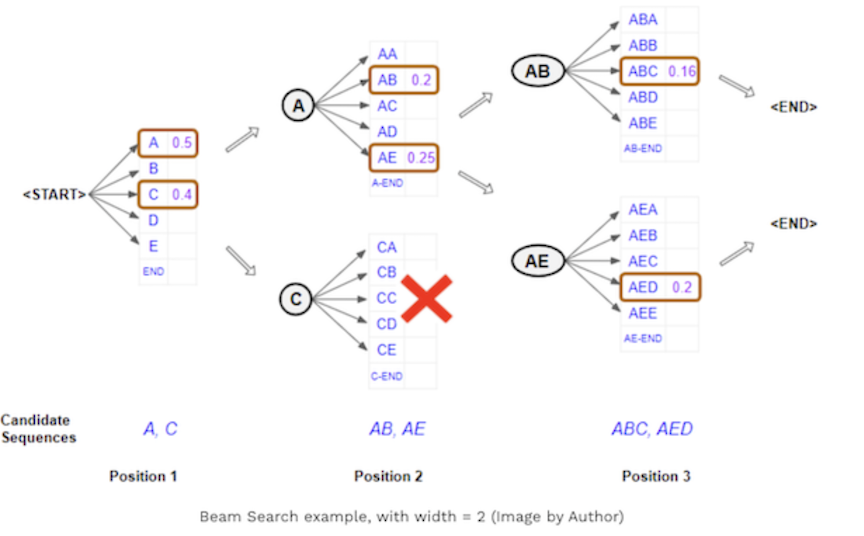

### The Basic Idea

Maintain a list of at most **B** incomplete sentences. This list is called the **beam** or priority queue `PQ`.

Each partial sentence should store:

```python
(tokens_so_far, sum_log_probs)
```

where `sum_log_probs` is the sum of the original, untempered log probabilities of the tokens generated so far.

Start with:

```python
PQ = [
    (['<s>'], 0.0)
]
```

At each iteration:

1. For every partial sentence currently in `PQ`, generate **C** possible one-token continuations.
2. If a continuation ends with `</s>`:
   - compute its perplexity;
   - move it to a separate list called `Finished`.
3. Otherwise:
   - keep it as an unfinished candidate.
4. Rank the unfinished candidates by their accumulated log probability.
5. Keep only the best **B** candidates and use them as the new `PQ`.

Repeat until you have collected 10 completed sentences or reached the maximum generation length.

---

### Why We Can Rank by Sum of Log Probabilities

In Problem Three, you used **Average Log Probability (ALP)** to compare sequences of different lengths.

During one iteration of beam search, however, all unfinished candidates have the same length because each one has just been extended by exactly one token.

Therefore, ranking candidates by:

```python
sum_log_probs
```

produces the same ordering as ranking them by ALP.

For completed sentences, which may have different lengths, continue to use **perplexity** for comparison.

---

### Beam Width and Continuation Width

Beam search uses two important parameters:

- **Beam width `B`**: the number of partial sentences retained after each iteration.
- **Continuation width `C`**: the number of possible next-token continuations generated from each partial sentence.

A larger `B` explores more possible paths but requires more computation.

A larger `C` produces more possible continuations before pruning.

In this problem, use:

```python
B = 5
C = 5
```

---

### Temperature Still Matters

The next-token continuations should still be sampled using **temperature-controlled sampling**, exactly as in Problems Two and Three.

Thus:

- low temperature favors high-probability continuations;
- high temperature explores a wider range of possible continuations.

However, once a token is sampled, score it using its original **untempered** log probability.

This means temperature controls **exploration**, while the beam keeps the highest-scoring partial sequences.

---

### Similar Sentences Are Expected

Beam search is designed to find high-probability sequences, not to maximize diversity.

As a result, several completed sentences may share long prefixes or differ only near the end.

This is especially likely when one partial sentence receives a strong score early in the search and several surviving beam candidates become descendants of that same prefix.

This behavior is normal and is an important contrast with ordinary temperature sampling.

---

### Maximum Length

Use the same maximum generation length as in the previous problems.

Stop expanding the beam after **40 generated tokens**, even if fewer than 10 completed sentences have been found.

If fewer than 10 sentences are completed, print the completed sentences that were found.

---

### To Do

### A. Write a one-step extension function

Write a function that takes:

```python
(tokens_so_far, sum_log_probs)
```

and returns a new pair after generating exactly one additional token.

The function should:

- use the trigram context when available;
- back off to the bigram context when necessary;
- sample using the specified temperature;
- add the sampled token's original log probability to `sum_log_probs`.

---

### B. Implement beam search

Using:

```python
B = 5
C = 5
```

implement the beam-search procedure described above.

At each iteration:

- generate `C` continuations from each partial sentence in `PQ`;
- move completed sentences to `Finished`;
- optionally remove exact duplicate candidates;
- rank unfinished candidates by `sum_log_probs`;
- retain only the best `B`.

Continue until either:

- 10 completed sentences have been collected, or
- the 40-token maximum has been reached.

---

### C. Compare three temperatures

Run beam search using:

```python
0.2
1.0
5.0
```

For each temperature:

- collect up to **10 completed sentences**;
- sort the completed sentences by increasing perplexity;
- print each sentence using `print_sentence()`;
- print its perplexity.

Compare the results across temperatures.

In particular, observe:

- sentence quality,
- perplexity,
- diversity,
- and the extent to which different beam-search results share common prefixes.

---

**Then answer the graded questions.**


### Graded Questions

#### Part 4A

During a single iteration of beam search, why is it valid to rank unfinished candidate sentences using `sum_log_probs` rather than Average Log Probability (ALP)?

Set `a4a` to the number of the best answer.

1. `sum_log_probs` and ALP are always numerically equal.
2. All unfinished candidates at that iteration have the same length, so dividing by length would not change their ranking.
3. ALP can only be computed after `</s>` has been generated.
4. Beam search does not need to compare probabilities until generation is complete.

In [36]:
# Your answer here

a4a = 0                     # Replace with one of 1, 2, 3, 4

In [37]:
# Graded Answer
# DO NOT change this cell in any way and do not make any other assignments to variable a3a
print(f'a4a = {a4a}') 


a4a = 0


#### Part 4B

What is the role of the beam width `B` in beam search?

Set `a4b` to the number of the best answer.

1. It determines how many possible next tokens are sampled from each candidate.
2. It determines the maximum sentence length.
3. It determines how many unfinished candidate sentences are retained after each iteration.
4. It determines the temperature used for sampling.

In [38]:
# Your answer here

a4b = 0                     # Replace with one of 1, 2, 3, 4

In [39]:
# Graded Answer
# DO NOT change this cell in any way and do not make any other assignments to variable a4b in this problem         

print(f'a4b = {a4b}') 


a4b = 0


#### Part 4C

Compare the sentences produced by beam search with those produced by ordinary temperature sampling in Problem Two.

Briefly describe what you observed about:

- sentence quality,
- perplexity,
- diversity,
- and the tendency of several beam-search sentences to share the same or similar prefixes.

Why does beam search tend to produce several closely related sentences?

Store your response in `a4c`.

In [40]:
# Your answer here, NOT in the next cell

a4c = """
Write your reflection here.
"""

In [41]:
# Graded Answer
# DO NOT change this cell in any way and do not make any other assignments to variable a1 in this problem         

print(f'a4c = {a4c}') 


a4c = 
Write your reflection here.



## Appendix: Using Log Probabilities in N-Gram Models

In an N-gram language model, the probability of a sequence is obtained by multiplying the conditional probabilities of the tokens that are predicted.

For a tokenized sentence

$$
[t_1, t_2, \dots, t_n]
$$

where $t_1 = \texttt{<s>}$, the model predicts the remaining $n-1$ tokens:

$$
P(t_2, t_3, \dots, t_n \mid t_1)
=
\prod_{i=2}^{n}
P(t_i \mid \text{context}_i)
$$

For our trigram model, the context normally consists of the previous two tokens. When that trigram context is unavailable, we back off to the previous one-token bigram context.

---

### Why Use Log Probabilities?

Probabilities are numbers between 0 and 1. When many probabilities are multiplied together, the result can become extremely small.

The Austen corpus used in this homework contains approximately **432,000 tokens**, and its longest sentence contains **303 tokens**.

Suppose, just for illustration, that the average conditional probability of each predicted token were $0.1$.

For a 303-token sentence, the product would be approximately:

$$
(0.1)^{302} = 10^{-302}
$$

This is extremely small, although it is still representable using standard double-precision floating-point numbers.

But if the average conditional probability were $0.01$, then:

$$
(0.01)^{302} = 10^{-604}
$$

which is too small to represent in ordinary double precision and would **underflow to 0**.

This is why language models normally perform probability calculations in **log space**.

---

### Some Examples of Log Probabilities

We use the natural logarithm, `log`.

Since probabilities lie in the range

$$
0 \le P \le 1,
$$

their log probabilities lie in the range

$$
-\infty \le \log P \le 0.
$$

For example:

| Probability | Log Probability |
|---:|---:|
| $1.0$ | $0.0$ |
| $1/2$ | $-0.6931$ |
| $1/3$ | $-1.0986$ |
| $1/4$ | $-1.3863$ |
| $0.01$ | $-4.6052$ |
| $10^{-10}$ | $-23.0259$ |
| $10^{-1000}$ | $-2302.5851$ |

Notice that:

- more likely events have log probabilities closer to **0**;
- less likely events have increasingly negative log probabilities.

---

### The Log-Space Trick

The key identity is:

$$
\log(ab) = \log(a) + \log(b)
$$

Therefore, instead of multiplying many small probabilities:

$$
P_1 P_2 P_3 \cdots P_k,
$$

we add their log probabilities:

$$
\log P_1 + \log P_2 + \log P_3 + \cdots + \log P_k.
$$

For a generated sentence, this gives:

$$
\log P(\text{sentence})
=
\sum_{i=2}^{n}
\log P(t_i \mid \text{context}_i)
$$

In the homework, we store this quantity as:

```python
sum_log_probs
```

> Using log probabilities therefore lets us replace multiplication of very small probabilities with addition of manageable log probabilities. In this homework, `sum_log_probs` stores this accumulated score. When ordinary probabilities are needed for sampling, convert back using `exp()`. See Problem Three for how `sum_log_probs` is converted to ALP and perplexity.